In [4]:
# ============================================================
# 批量检测：用预训练 yolov8n-pose 提取 action_train 全部图片的人体关键点
# ============================================================
import sys
# ultralytics 源码位于 week12 目录，加入模块搜索路径
sys.path.insert(0, r"d:\project\step1\week12\ultralytics-8.4.113")

from ultralytics import YOLO
from pathlib import Path
import glob

# 加载 COCO 预训练姿态模型（17 个人体关键点），不训练，直接推理
model = YOLO(r"d:\project\step1\week12\yolov8n-pose.pt")

ACTION_ROOT = Path(r"d:\project\step1\week13\action_train")     # 数据集根目录
OUT_DIR = Path(r"d:\project\step1\week13\action_train_pose_out")  # 可视化结果输出目录
OUT_DIR.mkdir(exist_ok=True)

images = sorted(glob.glob(str(ACTION_ROOT / "*" / "*.jpg")))
print(f"共 {len(images)} 张图片")

# 保存每张图的关键点特征（用于后续动作识别）
results_all = {}

for i, img in enumerate(images, 1):
    r = model.predict(img, imgsz=640, conf=0.25, verbose=False,
                      save=True, project=str(OUT_DIR), name="detect",
                      exist_ok=True)[0]
    n = len(r.boxes)
    if n > 0 and r.keypoints is not None:
        kpts = r.keypoints.data[0].cpu().numpy()   # (17, 3): 每个关键点的 x, y, 置信度
        vis = int((kpts[:, 2] > 0.5).sum())        # 可见（置信度>0.5）的关键点数
        results_all[Path(img)] = kpts
        print(f"[{i}/{len(images)}] {Path(img).parent.name}/{Path(img).name}: "
              f"检测 {n} 人, 可见关键点 {vis}/17, 置信度 {r.boxes[0].conf[0]:.2f}")
    else:
        print(f"[{i}/{len(images)}] {Path(img).name}: 未检测到目标")

print(f"\n检测完成，可视化结果已保存到: {OUT_DIR / 'detect'}")
print(f"成功提取关键点的图片数: {len(results_all)} / {len(images)}")

共 36 张图片
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[1/36] 01_left/raw_12.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.92
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[2/36] 01_left/raw_13.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.91
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[3/36] 01_left/raw_14.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.90
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[4/36] 01_left/raw_15.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.90
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[5/36] 02_right/raw_40.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.91
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[6/36] 02_right/raw_47.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.90
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[7/36] 02_right/raw_48.jpg: 检测 1 人, 可见关键点 13/17, 置信度 0.91
Results saved to D:\project\step1\week13\action_train_pose_out\detect
[8/36] 02_right/raw_49.jpg: 检

动作类别: ['01_left', '02_right', '03_pause', '04_shut', '05_up', '06_0k', '07_right_fly', '08_left_fly', '09_open']


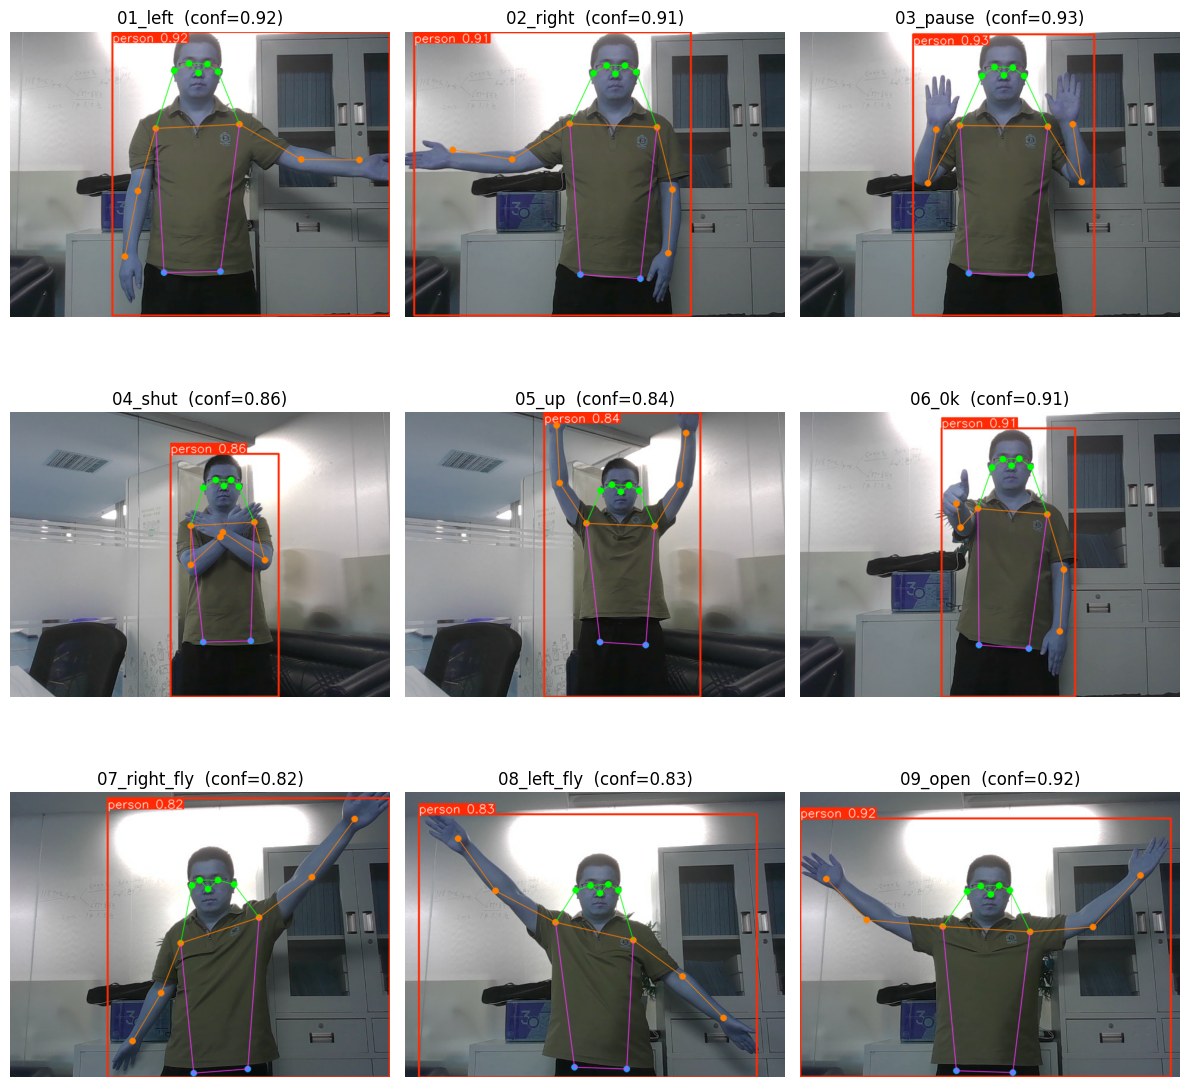

In [2]:
# ============================================================
# 在 Notebook 中展示每个动作类别的关键点检测结果
# ============================================================
import matplotlib.pyplot as plt
import glob

classes = sorted([p.name for p in ACTION_ROOT.iterdir() if p.is_dir()])
print("动作类别:", classes)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, cls in zip(axes.ravel(), classes):
    img = sorted(glob.glob(str(ACTION_ROOT / cls / "*.jpg")))[0]   # 每类取第一张
    r = model.predict(img, imgsz=640, conf=0.25, verbose=False)[0]
    if len(r.boxes):
        ax.imshow(r.plot())   # r.plot() 返回带关键点与骨架的可视化图
        ax.set_title(f"{cls}  (conf={r.boxes[0].conf[0]:.2f})")
    else:
        ax.set_title(f"{cls}  (未检测到)")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# 基于 YOLOv8-pose 的关键点特征提取类（PoseDetect）
# 功能：加载姿态模型 -> 从单帧提取 34 维归一化特征 -> 遍历数据集生成 feats.txt
# ============================================================
import sys
sys.path.insert(0, r"d:\project\step1\week12\ultralytics-8.4.113")

import os
import json
import cv2
import numpy as np
from ultralytics import YOLO


class PoseDetect:
    """人体姿态关键点检测与特征提取"""

    def __init__(self, model_path=r"d:\project\step1\week12\yolov8n-pose.pt"):
        self.model = self.load_model(model_path)

    def load_model(self, model_path):
        """加载 YOLOv8-pose 模型"""
        return YOLO(model_path)

    def get_frame_feat(self, img_data):
        """输入一帧 RGB 图像 (np.ndarray)，返回 34 维归一化特征 (17 关键点 × x,y)
        以双肩中点为原点、肩宽为尺度归一化（抗平移/缩放）；不可见关键点置 0
        未检测到人体时返回空列表"""
        results = self.model(img_data)
        r = results[0]
        if r.keypoints is None or len(r.boxes) == 0:
            return []
        kpts = r.keypoints.data[0].cpu().numpy()   # (17, 3): x, y, conf
        x, y, conf = kpts[:, 0], kpts[:, 1], kpts[:, 2]
        cx = (x[5] + x[6]) / 2                     # 双肩中点 (COCO: 5=左肩, 6=右肩)
        cy = (y[5] + y[6]) / 2
        scale = np.linalg.norm([x[6] - x[5], y[6] - y[5]]) or 1.0   # 肩宽
        nx = (x - cx) / scale                      # 归一化 x
        ny = (y - cy) / scale                      # 归一化 y
        mask = conf < 0.5                          # 不可见的关键点
        nx[mask] = 0.0
        ny[mask] = 0.0
        return np.stack([nx, ny], axis=1).reshape(-1).tolist()   # 34 维特征

    def init_feats(self, img_paths, out_file="feats.txt"):
        """遍历数据集每个动作类别文件夹，提取关键点特征写入 feats.txt
        每行格式: [动作类别, [34个特征值...]]，JSON 格式"""
        img_labels = sorted(os.listdir(img_paths))
        with open(out_file, "w", encoding="utf-8") as f:
            for img_label in img_labels:
                img_label_path = os.path.join(img_paths, img_label)
                for img_name in os.listdir(img_label_path):
                    img_path = os.path.join(img_label_path, img_name)
                    img_data = cv2.imread(img_path)
                    img_data = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB)  # BGR -> RGB
                    feat = self.get_frame_feat(img_data)
                    feats = [img_label, feat]          # [类别标签, 特征]
                    out_feat = json.dumps(feats)
                    f.write(out_feat + "\n")
                    print(f"已处理: {img_label}/{img_name}, 特征维度={len(feat)}")
        print(f"\n特征已写入: {out_file}")


# 使用示例：遍历 action_train，生成 feats.txt
detector = PoseDetect()
detector.init_feats(r"d:\project\step1\week13\action_train",
                    r"d:\project\step1\week13\feats.txt")


0: 480x640 1 person, 32.4ms
Speed: 2.9ms preprocess, 32.4ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
已处理: 01_left/raw_12.jpg, 特征维度=34

0: 480x640 1 person, 32.4ms
Speed: 3.4ms preprocess, 32.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
已处理: 01_left/raw_13.jpg, 特征维度=34

0: 480x640 1 person, 32.2ms
Speed: 3.1ms preprocess, 32.2ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
已处理: 01_left/raw_14.jpg, 特征维度=34

0: 480x640 1 person, 32.3ms
Speed: 3.0ms preprocess, 32.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
已处理: 01_left/raw_15.jpg, 特征维度=34

0: 480x640 1 person, 28.9ms
Speed: 3.5ms preprocess, 28.9ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
已处理: 02_right/raw_40.jpg, 特征维度=34

0: 480x640 1 person, 7.7ms
Speed: 1.1ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
已处理: 02_right/raw_47.jpg, 特征维度=34

0: 480x640 1 person, 7.9ms
Speed: 0.9ms prepr

In [15]:
# ============================================================
# 构建特征向量库（模板库）—— 类封装
# 对应流程图左侧的"模板特征"部分
# ============================================================
import numpy as np

class PoseFeatureExtractor:
    """关键点特征提取器：17 个人体关键点 -> 34 维归一化特征向量"""
    COCO_SHOULDER_L, COCO_SHOULDER_R = 5, 6   # COCO 17 关键点: 左肩、右肩

    def __init__(self, conf_thr=0.5):
        self.conf_thr = conf_thr              # 关键点可见性置信度阈值

    def extract(self, kpts):
        """输入 (17,3) 关键点 [x, y, conf]，输出 34 维特征向量
        归一化：以双肩中点为原点、肩宽为尺度，抗平移和缩放"""
        x, y, conf = kpts[:, 0], kpts[:, 1], kpts[:, 2]
        cx = (x[self.COCO_SHOULDER_L] + x[self.COCO_SHOULDER_R]) / 2   # 肩中点
        cy = (y[self.COCO_SHOULDER_L] + y[self.COCO_SHOULDER_R]) / 2
        scale = np.linalg.norm([x[self.COCO_SHOULDER_R] - x[self.COCO_SHOULDER_L],
                                y[self.COCO_SHOULDER_R] - y[self.COCO_SHOULDER_L]]) or 1.0
        nx = (x - cx) / scale                  # 归一化 x
        ny = (y - cy) / scale                  # 归一化 y
        mask = conf < self.conf_thr            # 不可见的关键点
        nx[mask] = 0.0
        ny[mask] = 0.0
        return np.stack([nx, ny], axis=1).reshape(-1)   # 34 维特征向量


class FeatureLibrary:
    """特征向量库（模板库）：按动作类别组织模板特征"""

    def __init__(self, extractor, results_all):
        self.extractor = extractor
        self.library = {}                      # {动作类别: [特征1, 特征2, ...]}
        for img_path, kpts in results_all.items():
            cls = img_path.parent.name
            self.library.setdefault(cls, []).append(extractor.extract(kpts))

    def classes(self):
        """返回所有动作类别（排序后）"""
        return sorted(self.library.keys())

    def templates(self, cls):
        """返回某动作的全部模板特征"""
        return self.library[cls]

    def total(self):
        """返回模板总数"""
        return sum(len(v) for v in self.library.values())

    def describe(self):
        """打印库结构"""
        for cls, feats in self.library.items():
            print(f"{cls}: {len(feats)} 个模板特征, 维度 {feats[0].shape[0]}")
        print(f"\n共 {len(self.library)} 类动作, 总模板数 {self.total()}")


# 使用：特征提取器 + 特征向量库
extractor = PoseFeatureExtractor(conf_thr=0.5)
feature_library = FeatureLibrary(extractor, results_all)
feature_library.describe()

01_left: 4 个模板特征, 维度 34
02_right: 4 个模板特征, 维度 34
03_pause: 4 个模板特征, 维度 34
04_shut: 4 个模板特征, 维度 34
05_up: 4 个模板特征, 维度 34
06_0k: 4 个模板特征, 维度 34
07_right_fly: 4 个模板特征, 维度 34
08_left_fly: 4 个模板特征, 维度 34
09_open: 4 个模板特征, 维度 34

共 9 类动作, 总模板数 36


In [11]:
# ============================================================
# 前向推理：距离匹配 + 前 m 名投票 —— 类封装
# 对应流程图主流程：计算距离 -> 排序选最小 -> 检查前m个距离中重复次数 -> n > 阈值?
# ============================================================

class PoseActionRecognizer:
    """动作识别器：基于模板特征库做最近邻 + 投票"""

    def __init__(self, feature_library, m=3, threshold=1):
        self.library = feature_library.library   # 特征向量库 {动作: [特征...]}
        self.m = m                               # 取前 m 个最近模板
        self.threshold = threshold               # 投票阈值：n > threshold 才确认

    def _distances(self, feat):
        """步骤1: 计算与每个模板特征的距离 -> [(距离, 动作), ...]"""
        dists = []
        for cls, feats in self.library.items():
            for tf in feats:
                dists.append((np.linalg.norm(feat - tf), cls))
        return dists

    def predict(self, feat):
        """输入特征 -> (预测动作, 投票数n, 最小距离, 前m名列表)"""
        # 步骤2: 排序，选择最小距离对应的动作
        dists = sorted(self._distances(feat), key=lambda d: d[0])
        min_dist, best_cls = dists[0]
        top = dists[:self.m]
        # 步骤3: 检查该动作在前 m 个距离中的重复次数 n
        n = sum(1 for _, c in top if c == best_cls)
        # 步骤4: n > 阈值 ? 预测动作 : 未知动作
        pred = best_cls if n > self.threshold else "未知动作"
        return pred, n, min_dist, top


# 演示：取 01_left 中的一张图当作"实时帧"
recognizer = PoseActionRecognizer(feature_library, m=3, threshold=1)

query = sorted((ACTION_ROOT / "01_left").glob("*.jpg"))[0]
r = model.predict(str(query), imgsz=640, conf=0.25, verbose=False)[0]
query_feat = extractor.extract(r.keypoints.data[0].cpu().numpy())

pred, n, min_dist, top = recognizer.predict(query_feat)

print(f"查询帧: {query.name}   (真实动作: {query.parent.name})\n")
print(f"前 {recognizer.m} 个最近模板距离:")
for i, (d, c) in enumerate(top, 1):
    print(f"  #{i}  距离 = {d:.4f}   动作 = {c}")
print(f"\n投票: 动作 '{pred}' 在前 {recognizer.m} 名中出现 {n} 次  (阈值要求 n > {recognizer.threshold})")
print(f"预测结果: {pred}")

查询帧: raw_12.jpg   (真实动作: 01_left)

前 3 个最近模板距离:
  #1  距离 = 0.0000   动作 = 01_left
  #2  距离 = 0.0783   动作 = 01_left
  #3  距离 = 0.0785   动作 = 01_left

投票: 动作 '01_left' 在前 3 名中出现 3 次  (阈值要求 n > 1)
预测结果: 01_left


In [12]:
# ============================================================
# 留一法评估：每张图当"查询帧"，其余 35 张当模板
# 验证整个"特征库 + 前向推理"流程的识别准确率
# ============================================================
correct = 0
total = 0
for img_path, kpts in results_all.items():
    true_cls = img_path.parent.name
    # 构建"去掉自身"的临时特征库
    others = {p: k for p, k in results_all.items() if p != img_path}
    lib = FeatureLibrary(extractor, others)
    recognizer = PoseActionRecognizer(lib, m=3, threshold=1)

    pred, n, md, _ = recognizer.predict(extractor.extract(kpts))
    total += 1
    correct += (pred == true_cls)
    mark = "√" if pred == true_cls else "×"
    print(f"{mark} {img_path.parent.name}/{img_path.name}: 真实={true_cls}, 预测={pred}, n={n}")

print(f"\n留一法识别准确率: {correct}/{total} = {correct/total:.1%}")

√ 01_left/raw_12.jpg: 真实=01_left, 预测=01_left, n=3
√ 01_left/raw_13.jpg: 真实=01_left, 预测=01_left, n=3
√ 01_left/raw_14.jpg: 真实=01_left, 预测=01_left, n=3
√ 01_left/raw_15.jpg: 真实=01_left, 预测=01_left, n=3
√ 02_right/raw_40.jpg: 真实=02_right, 预测=02_right, n=3
√ 02_right/raw_47.jpg: 真实=02_right, 预测=02_right, n=3
√ 02_right/raw_48.jpg: 真实=02_right, 预测=02_right, n=3
√ 02_right/raw_49.jpg: 真实=02_right, 预测=02_right, n=3
√ 03_pause/raw_53.jpg: 真实=03_pause, 预测=03_pause, n=3
√ 03_pause/raw_54.jpg: 真实=03_pause, 预测=03_pause, n=3
√ 03_pause/raw_55.jpg: 真实=03_pause, 预测=03_pause, n=3
√ 03_pause/raw_58.jpg: 真实=03_pause, 预测=03_pause, n=3
√ 04_shut/raw_17.jpg: 真实=04_shut, 预测=04_shut, n=3
√ 04_shut/raw_19.jpg: 真实=04_shut, 预测=04_shut, n=3
√ 04_shut/raw_26.jpg: 真实=04_shut, 预测=04_shut, n=3
√ 04_shut/raw_7.jpg: 真实=04_shut, 预测=04_shut, n=3
√ 05_up/raw_29.jpg: 真实=05_up, 预测=05_up, n=3
√ 05_up/raw_31.jpg: 真实=05_up, 预测=05_up, n=3
√ 05_up/raw_34.jpg: 真实=05_up, 预测=05_up, n=3
√ 05_up/raw_36.jpg: 真实=05_up, 预测=05_up, n=3
√

# 📌 流程总结：人体姿态关键点之动作识别

## 整体流水线（6 步）

| 步骤 | 单元格 | 做了什么 | 关键产出 |
|---|---|---|---|
| 1 | 批量检测 | 用预训练 `yolov8n-pose` 对 `action_train` 36 张图检测人体关键点 | `model`、`results_all`（17 关键点/张） |
| 2 | 可视化 | 3×3 网格展示各类动作的关键点与骨架 | 可视化图 |
| 3 | 特征提取 | `PoseDetect` 类：从单帧提取 34 维归一化特征，遍历数据集写入 `feats.txt` | `feats.txt` |
| 4 | 特征向量库 | `PoseFeatureExtractor` + `FeatureLibrary`：关键点归一化为 34 维特征，按类别建模板库 | `feature_library`（9 类 × 4 模板） |
| 5 | 前向推理 | `PoseActionRecognizer`：距离匹配 → 排序 → 前 m 名投票 → 阈值判断 | 预测动作 / 未知动作 |
| 6 | 留一法评估 | 每张图当查询帧、其余 35 张当模板，统计识别准确率 | 准确率（36/36 = 100%） |

## 与流程图对应

```mermaid
flowchart TD
    A[视频采集的图像] --> B[每一帧图像的特征]
    B --> C[计算与每个标签片段特征的距离]
    C --> D[排序，选择最小距离对应的动作]
    D --> E[检查该动作在前 m 个距离中重复次数]
    E --> F{n > 阈值?}
    F -- YES --> G[预测动作]
    F -- NO --> H[未知动作]
```

- **步骤 1~3** 对应"每一帧图像的特征"：把原始图像变成关键点特征向量
- **步骤 4** 对应左侧"模板特征"（动作A/B 的特征1/2/3）：按类别保存的模板库
- **步骤 5** 对应主流程：计算距离 → 排序选最小 → 前 m 名投票 → n > 阈值 判断
- **步骤 6** 是对整个流程的验证

## 特征方案（已统一为 34 维）

单元格 3 与单元格 4 均输出 **34 维归一化特征**（17 关键点 × x/y 坐标）：

- 以**双肩中点**为原点、**肩宽**为尺度做归一化 → 抗平移、抗缩放
- 置信度 < 0.5 的不可见关键点坐标置 0
- 置信度本身不进入特征向量（只用于判断可见性）

| 位置 | 提取器 | 特征去向 |
|---|---|---|
| 单元格 3 | `PoseDetect` | 写入 `feats.txt`（落盘） |
| 单元格 4 | `PoseFeatureExtractor` | 内存中构建 `feature_library` 模板库 |

## 结果与注意事项

- 留一法准确率 **36/36 = 100%**，但这是小样本 + 同源数据的乐观结果，真实泛化需用新拍视频帧验证
- 关键点检测用的是 COCO 预训练模型（人体 17 点），未训练；若工业场景检测不准，需按 week12 流程标注 + 微调
- 识别核心是最近邻 + 投票：前 m 名中同一动作出现次数 n 超过阈值才确认，否则判为"未知动作"


# 🧠 Br35HDet 脑肿瘤分割训练结果总结

## 训练配置

| 项目 | 值 |
|---|---|
| 任务 | YOLOv8-seg 实例分割（1 类：tumor） |
| 模型 | `yolov8s-seg.pt`（COCO 预训练 → 迁移学习） |
| 数据集 | 198 训练 / 50 验证 |
| 超参数 | `imgsz=512, batch=16, epochs=100, amp=False` |
| 训练耗时 | 634 秒（约 10.6 分钟） |
| 输出目录 | `week13/runs/seg_train/` |

## 最终指标（epoch 100）

| 指标 | 检测框(B) | 分割掩码(M) |
|---|---|---|
| Precision | 0.894 | 0.894 |
| Recall | 0.898 | 0.898 |
| mAP50 | **0.945** | **0.919** |
| mAP50-95 | **0.813** | **0.763** |

最优权重 `best.pt` 在第 **97 轮**：mAP50-95(B)=0.816、mAP50-95(M)=0.769、mAP50(M)=0.921

## 收敛情况（无过拟合 ✅）

| epoch | val_box | val_seg | mAP50-95(B) | mAP50-95(M) |
|---|---|---|---|---|
| 10 | 1.80 | 30.4 | 0.298 | 0.157 |
| 50 | 0.68 | 1.49 | 0.757 | 0.707 |
| 90 | 0.70 | 1.28 | 0.787 | 0.754 |
| 100 | 0.61 | 1.25 | 0.813 | 0.763 |

验证损失全程持续下降、无反弹 → 训练充分且未过拟合。

## 与上次训练对比（超参数调优效果）

| 指标 | imgsz=256, batch=4（上次） | imgsz=512, batch=16（本次） | 提升 |
|---|---|---|---|
| mAP50-95 (框) | 0.778 | **0.816** | +4.9% |
| mAP50-95 (掩码) | 0.708 | **0.769** | +8.6% |
| mAP50 (框) | 0.941 | 0.921* | — |

\* 本次 best 轮的 mAP50 略低但 mAP50-95 更高（整体更优）；最终轮 mAP50(B)=0.945 全面领先。

**结论**：`imgsz=512` 让掩码边缘更精细（掩码指标提升最大），`batch=16` 使训练更充分；总耗时仅多 ~2 分钟，**512/16 定为正式参数**。

## 下游应用

用训练好的 `best.pt` 跑验证集抠出肿瘤并保存（`seg_detect.py` → `tumor_crop_out/`）：

- 10 张验证图抠出 9 个肿瘤，置信度 0.88~0.93
- 无肿瘤的背景图被正确"拒绝"（未检出）
